In [1]:
import os
from bs4 import BeautifulSoup
import time
from urllib.request import urlopen
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import array
import numpy as np
import logging
import requests
from requests.exceptions import RequestException
import send2trash
import re
import certifi
import io
from io import StringIO
from fuzzywuzzy import process
from tabulate import tabulate
import ssl
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from scipy.stats import pearsonr
import statsmodels.api as sm
pd.set_option('display.max_columns', None)
from nba_api.stats.static import players
from nba_api.stats.endpoints import leagueleaders
import itertools

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [8]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

for i, year in enumerate(years):
    year = str(year)
    if i != len(years) - 1:
        next_year = str(years[i + 1])
        years[i] = str(year) + "-" + next_year[2:]

years = years[0:9]
seas_ids = ['22015', '22016', '22017', '22018', '22019', '22020', '22021', '22022', '22023', '22024']

playtypes = ['Cut', 'Handoff', 'Isolation', 'OffScreen', 'Postup', 'PRBallHandler', 'PRRollman', 'OffRebound', 'Spotup', 'Transition']
tracking_types = ["Drives", "Defense", "CatchShoot", "Passing", "Possessions", "PullUpShot", "Rebounding", "ElbowTouch", "PostTouch", "PaintTouch"]

In [40]:
# The following code is necessary for API scraping and was found at the following link: https://github.com/basketballrelativity/synergy/blob/master/synergy_exploration.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import itertools

from PIL import Image
import time

from py_ball import synergy, leaderboard, team, league_dash, league_hustle

HEADERS = {'Connection': 'keep-alive',
           'Host': 'stats.nba.com',
           'Origin': 'http://stats.nba.com',
           'Upgrade-Insecure-Requests': '1',
           'Referer': 'stats.nba.com',
           'x-nba-stats-origin': 'stats',
           'x-nba-stats-token': 'true',
           'Accept-Language': 'en-US,en;q=0.9',
           "X-NewRelic-ID": "VQECWF5UChAHUlNTBwgBVw==",
           'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6)' +\
                         ' AppleWebKit/537.36 (KHTML, like Gecko)' + \
                         ' Chrome/81.0.4044.129 Safari/537.36'}

pd.options.mode.chained_assignment = None  # Disabling pandas SetWithCopyWarnings

https://github.com/basketballrelativity/synergy/blob/master/synergy_exploration.ipynb

https://github.com/swar/nba_api/blob/master/docs/nba_api/stats/library/parameters.md#PlayType

https://github.com/basketballrelativity/py_ball/wiki

https://www.sloansportsconference.com/research-papers/nba-lineup-analysis-on-clustered-player-tendencies-a-new-approach-to-the-positions-of-basketball-modeling-lineup-efficiency

https://fansided.com/2020/03/02/nylon-calculus-optimizing-nba-lineup-fit/

In [ ]:
league_id = '00'
season_year = '2016-17'
season_type = 'Regular Season'
per_mode = 'Totals'
player_or_team = 'P'
play_type = 'PRBallHandler'
type_grouping = 'offensive'

synergy_data = synergy.Synergy(headers=HEADERS,
                               endpoint='synergyplaytypes',
                               league_id=league_id,
                               season_year=season_year,
                               season_type=season_type,
                               per_mode=per_mode,
                               player_or_team=player_or_team,
                               play_type=play_type,
                               type_grouping=type_grouping)
synergy_df = pd.DataFrame(synergy_data.data['SynergyPlayType'])

synergy_df

In [101]:
# Scraping playtype data

#for year in years:
league_id = '00'
season_year = years[8]
season_type = 'Regular Season'
per_mode = 'Totals'
player_or_team = 'P'
for playtype in playtypes:
    play_type = playtype
    type_grouping = 'offensive'

    synergy_data = synergy.Synergy(headers = HEADERS,
                                endpoint = 'synergyplaytypes',
                                league_id = league_id,
                                season_year = season_year,
                                season_type = season_type,
                                per_mode = per_mode,
                                player_or_team = player_or_team,
                                play_type = play_type,
                                type_grouping = type_grouping)
    synergy_df = pd.DataFrame(synergy_data.data['SynergyPlayType'])

    indices_to_drop = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23]
    synergy_df = synergy_df.drop(synergy_df.columns[indices_to_drop], axis = 1)

    playtype_upper = play_type.upper()

    synergy_df.columns.values[2] = playtype_upper + "_POSS"
    synergy_df.columns.values[3] = playtype_upper + "_PTS"

    synergy_df.to_csv(f"{season_year}/{season_year}_{play_type}.csv", index = False)

    time.sleep(10)

In [23]:
# Scraping Hustle data

#for i, year in enumerate(years):
league_id = '00'
per_mode = 'Totals'
plus_minus = 'N'
rank = 'N'
pace_adjust = 'N'
period = '0'
vs_conference = ''
last_n_games = ''
measure_type = 'Defense'
season = years[8]
season_type = 'Regular Season'


hustle_data = league_hustle.LeagueHustle(headers = HEADERS,
                            endpoint = 'leaguehustlestatsplayer',
                            per_mode = per_mode,
                            plus_minus = plus_minus,
                            rank = rank,
                            pace_adjust = pace_adjust,
                            period = period,
                            vs_conference = vs_conference,
                            measure_type = measure_type,
                            season = season,
                            season_type = season_type)
hustle_df = pd.DataFrame(hustle_data.data['HustleStatsPlayer'])

hustle_df.to_csv(f"{season}/{season}_hustle.csv", index = False)
# print(f"{season_year} data scraped.")

# time.sleep(10)
hustle_df

,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,AGE,G,MIN,CONTESTED_SHOTS,CONTESTED_SHOTS_2PT,CONTESTED_SHOTS_3PT,DEFLECTIONS,CHARGES_DRAWN,SCREEN_ASSISTS,SCREEN_AST_PTS,OFF_LOOSE_BALLS_RECOVERED,DEF_LOOSE_BALLS_RECOVERED,LOOSE_BALLS_RECOVERED,PCT_LOOSE_BALLS_RECOVERED_OFF,PCT_LOOSE_BALLS_RECOVERED_DEF,OFF_BOXOUTS,DEF_BOXOUTS,BOX_OUT_PLAYER_TEAM_REBS,BOX_OUT_PLAYER_REBS,BOX_OUTS,PCT_BOX_OUTS_OFF,PCT_BOX_OUTS_DEF,PCT_BOX_OUTS_TEAM_REB,PCT_BOX_OUTS_REB
0,1631260,AJ Green,1610612749,MIL,24.0,56,614.0,71,41,30,27,4,7,16,1,10,11,0.091,0.909,2,9,11,2,11,0.182,0.818,1.000,0.182
1,1631100,AJ Griffin,1610612737,ATL,20.0,20,171.0,19,12,7,4,0,2,5,2,3,5,0.400,0.600,0,2,2,0,2,0.000,1.000,1.000,0.000
2,1630639,AJ Lawson,1610612742,DAL,23.0,42,311.0,40,27,13,12,0,8,17,2,5,7,0.286,0.714,0,5,4,2,5,0.000,1.000,0.800,0.400
3,203932,Aaron Gordon,1610612743,DEN,28.0,73,2297.0,346,237,109,101,2,92,225,23,20,43,0.535,0.465,18,27,44,32,45,0.400,0.600,0.978,0.711
4,1628988,Aaron Holiday,1610612745,HOU,27.0,78,1269.0,151,83,68,76,1,16,36,12,12,24,0.500,0.500,1,30,27,6,31,0.032,0.968,0.871,0.194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,203897,Zach LaVine,1610612741,CHI,29.0,25,872.0,128,48,80,41,0,10,21,7,6,13,0.538,0.462,0,3,3,3,3,0.000,1.000,1.000,1.000
568,1630285,Zavier Simpson,1610612763,MEM,27.0,7,161.0,22,8,14,11,0,0,0,3,3,6,0.500,0.500,0,1,1,0,1,0.000,1.000,1.000,0.000
569,1630192,Zeke Nnaji,1610612743,DEN,23.0,58,576.0,214,152,62,35,0,87,204,3,4,7,0.429,0.571,11,26,36,19,37,0.297,0.703,1.000,0.528
570,1630533,Ziaire Williams,1610612763,MEM,22.0,51,1038.0,180,93,87,79,4,9,22,11,10,21,0.524,0.476,0,18,18,10,18,0.000,1.000,1.000,0.556


In [78]:
# Scraping all players for a season

for i, year in enumerate(years):
    league_id = '00'
    stat_category_ll = "PTS"
    season = year
    season_type = "Regular Season"
    player_or_team = "Player"
    game_scope = "Season"
    player_scope = "All Players"
    per_mode = "Totals"
    scope = "S"

    leader_data = leaderboard.LeaderBoard(headers=HEADERS,
                                endpoint='leagueleaders',
                                stat_category_ll=stat_category_ll,
                                season=season,
                                season_type=season_type,
                                player_or_team=player_or_team,
                                game_scope=game_scope,
                                player_scope=player_scope,
                                per_mode=per_mode,
                                scope=scope)
    leader_df = pd.DataFrame(leader_data.data['LeagueLeaders'])

    # #drop = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
    drop = [1, 3, 9, 12, 15, 20, 21, 22, 23, 25, 26, 27]
    # #23
    leader_df = leader_df.drop(leader_df.columns[drop], axis = 1)

    parts = season.split('-')
    beg_season = parts[0]

    leader_df["Season ID"] = "2" + str(beg_season)

    # drop_by_min = []
    # for i in range(len(leader_df)):
    #     minutes = int(leader_df.loc[i, "MIN"])
    #     if minutes < 15:
    #         drop_by_min.append(i)

    #leader_df = leader_df.drop(drop_by_min, axis = 0)

    for i in range(len(leader_df)):
        leader_df.loc[i, 'PTS_GAME'] = int(leader_df.loc[i, 'PTS']) / int(leader_df.loc[i, 'GP'])
        leader_df.loc[i, 'MIN_GAME'] = int(leader_df.loc[i, 'MIN']) / int(leader_df.loc[i, 'GP'])

    # drop_by_min = []
    # for i in range(len(leader_df)):
    #     minutes = int(leader_df.loc[i, "MIN_GAME"])
    #     if minutes < 15:
    #         drop_by_min.append(i)

    # leader_df = leader_df.drop(drop_by_min, axis = 0)

    time.sleep(5)

    print(f"{season} stats have been scraped.")

    leader_df.to_csv(f"{season}/{season}_all_players_try2.csv", index = False)

2015-16 stats have been scraped.
2016-17 stats have been scraped.
2017-18 stats have been scraped.
2018-19 stats have been scraped.
2019-20 stats have been scraped.
2020-21 stats have been scraped.
2021-22 stats have been scraped.
2022-23 stats have been scraped.
2023-24 stats have been scraped.


In [ ]:
# Scraping advanced player data

league_id = '00'
per_mode = 'Totals'
plus_minus = 'N'
rank = 'N'
pace_adjust = 'N'
measure_type = 'Advanced'
period = '0'
vs_conference = ''
last_n_games = '0'
location = ''
outcome = ''
for year in years:
    season = year
    vs_division = ''
    game_segment = ''
    month = '0'
    season_type = 'Regular Season'
    season_segment = ''
    game_scope = ''
    player_experience = ''
    player_position = ''
    starters_bench = ''

    player_data = league_dash.LeagueDash(headers=HEADERS,
                                endpoint='leaguedashplayerstats',
                                league_id = league_id,
                                per_mode = per_mode,
                                plus_minus = plus_minus,
                                rank = rank,
                                pace_adjust = pace_adjust,
                                measure_type = measure_type,
                                period = period,
                                vs_conference = vs_conference,
                                last_n_games = last_n_games,
                                location = location,
                                outcome = outcome,
                                season = season,
                                vs_division = vs_division,
                                game_segment = game_segment,
                                month = month,
                                season_type = season_type,
                                season_segment = season_segment,
                                game_scope = game_scope,
                                player_experience = player_experience,
                                player_position = player_position,
                                starters_bench = starters_bench)
    time.sleep(10)

    player_df = pd.DataFrame(player_data.data['LeagueDashPlayerStats'])
    player_df.to_csv(f"{season}/{season}_advanced.csv", index = False)

    print(f"{season} information scraped.")
    time.sleep(10)

2015-16 information scraped.
2016-17 information scraped.
2017-18 information scraped.
2018-19 information scraped.
2019-20 information scraped.
2020-21 information scraped.
2021-22 information scraped.
2022-23 information scraped.
2023-24 information scraped.


In [ ]:
# Scraping tracking data for every player/season

league_id = '00'
per_mode = 'Totals'
plus_minus = 'N'
rank = 'N'
pace_adjust = 'N'
measure_type = 'Advanced'
period = '0'
vs_conference = ''
last_n_games = '0'
location = ''
outcome = ''
for i in range(len(years)):
    season = years[i]
    vs_division = ''
    game_segment = ''
    month = '0'
    season_type = 'Regular Season'
    season_segment = ''
    game_scope = ''
    player_experience = ''
    player_position = ''
    starters_bench = ''
    for i in range(len(tracking_types)):
        pt_measure_type = tracking_types[i]

        tracking_data = league_dash.LeagueDash(headers=HEADERS,
                                    endpoint='leaguedashptstats',
                                    league_id = league_id,
                                    per_mode = per_mode,
                                    plus_minus = plus_minus,
                                    rank = rank,
                                    pace_adjust = pace_adjust,
                                    measure_type = measure_type,
                                    period = period,
                                    vs_conference = vs_conference,
                                    last_n_games = last_n_games,
                                    location = location,
                                    outcome = outcome,
                                    season = season,
                                    vs_division = vs_division,
                                    game_segment = game_segment,
                                    month = month,
                                    season_type = season_type,
                                    season_segment = season_segment,
                                    game_scope = game_scope,
                                    player_experience = player_experience,
                                    player_position = player_position,
                                    starters_bench = starters_bench,
                                    pt_measure_type = pt_measure_type)

        tracking_df = pd.DataFrame(tracking_data.data['LeagueDashPtStats'])
        tracking_df.to_csv(f"{season}/{season}_{pt_measure_type}.csv", index = False)

        print(f"{season} {pt_measure_type} information scraped.")
        time.sleep(10)

In [42]:
# # Adds in necessary stats to each player

# for i, year in enumerate(years):
#     # Try reading the file with different encodings
#     df = pd.read_csv(f"{year}/{year}_advanced.csv")

#     # try:
#     #     df = pd.read_csv(file_path, encoding='utf-8')
#     # except UnicodeDecodeError:
#     #     try:
#     #         df = pd.read_csv(file_path, encoding='latin1')
#     #     except UnicodeDecodeError:
#     #         df = pd.read_csv(file_path, encoding='iso-8859-1')

#     # index_drop = []
#     # for i in range(1, 22):
#     #     index_drop.append(i)

#     # # Drops necessary columns
#     # df = df.drop(df.columns[index_drop], axis = 1)

#     all_possessions = df['POSS'].tolist()
#     all_players = df["PLAYER_NAME"].tolist()
#     player_pie = df["PIE"].tolist()

#     # Adds in all statistics to the necessary player
#     all_df = pd.read_csv(f"{year}/{year}_all_players.csv")

#     for i in range(len(all_df)):
#         player = str(all_df.loc[i, "PLAYER"])
#         if player in all_players:
#             index = all_players.index(player)
#             all_df.loc[i, "POSS"] = all_possessions[index]
#             all_df.loc[i, "PIE"] = player_pie[index]

#     cs_df = pd.read_csv(f"{year}/{year}_CatchShoot.csv")
#     player_list = cs_df['PLAYER_NAME'].tolist()
    

#     all_df.to_csv(f"{year}/{year}_all_players.csv", index = False)

In [ ]:
# Adds in necessary stats to each player

for i, year in enumerate(years):
    # Try reading the file with different encodings
    df = pd.read_csv(f"{year}/{year}_advanced.csv")

    all_possessions = df['POSS'].tolist()
    all_players = df["PLAYER_NAME"].tolist()
    player_pie = df["PIE"].tolist()

    # Adds in all statistics to the necessary player
    all_df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")

    for i in range(len(all_df)):
        player = str(all_df.loc[i, "PLAYER"])
        if player in all_players:
            index = all_players.index(player)
            all_df.loc[i, "POSS"] = all_possessions[index]
            all_df.loc[i, "PIE"] = player_pie[index]

    # Adding in all statistics from the passing df
    pass_df = pd.read_csv(f"{year}/{year}_Passing.csv")
    pass_player_list = pass_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in pass_player_list:
            index = pass_player_list.index(player)
            all_df.loc[i, "Passes"] = pass_df.loc[index, 'PASSES_MADE']
            all_df.loc[i, "Passes_Gm"] = all_df.loc[i, "Passes"] / all_df.loc[i, 'GP']
            all_df.loc[i, "Passes_Rec_Gm"] = pass_df.loc[index, 'PASSES_RECEIVED'] / all_df.loc[i, 'GP']
            all_df.loc[i, "Pot_Asst_Gm"] = pass_df.loc[index, 'POTENTIAL_AST'] / all_df.loc[i, 'GP']
            all_df.loc[i, "Asst_Pts_Cr"] = pass_df.loc[index, 'AST_PTS_CREATED'] / all_df.loc[i, 'GP']
    
    # Adding in all statistics from drives df
    drive_df = pd.read_csv(f"{year}/{year}_Drives.csv")
    player_list = drive_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, "PLAYER"])
        if player in player_list:
            index = player_list.index(player)
            all_df.loc[i, "Drives_Gp"] = drive_df.loc[index, 'DRIVES'] / drive_df.loc[index, 'GP']
            all_df.loc[i, "Drive_Pts"] = drive_df.loc[index, 'DRIVE_PTS'] / all_df.loc[i, 'PTS']
            all_df.loc[i, 'Pass_Drive'] = drive_df.loc[index, 'DRIVE_PASSES'] / drive_df.loc[index, 'DRIVES']
            all_df.loc[i, 'Drive_Ast_Ast'] = drive_df.loc[index, 'DRIVE_AST'] / all_df.loc[i, 'AST']
            all_df.loc[i, 'Drive_Fga_Fga'] = drive_df.loc[index, 'DRIVE_FGA'] / all_df.loc[i, 'FGA']
            all_df.loc[i, 'Drive_Fta_Fta'] = drive_df.loc[index, 'DRIVE_FTA'] / all_df.loc[i, 'FTA']
            all_df.loc[i, 'Drive_Pass_Pass'] = drive_df.loc[index, 'DRIVE_PASSES'] / all_df.loc[i, 'Passes']

    # Adding in all statistics from defensive df
    def_df = pd.read_csv(f"{year}/{year}_Defense.csv")
    def_player_list = def_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in def_player_list:
            index = def_player_list.index(player)
            def_fga = def_df.loc[index, 'DEF_RIM_FGA']
            def_fgm = def_df.loc[index, 'DEF_RIM_FGM']
            all_df.loc[i, 'Def_Buckets'] = (def_fga - def_fgm) / all_df.loc[i, 'GP']

    # Adding in all statistics from Catch and Shoot df
    cs_df = pd.read_csv(f"{year}/{year}_CatchShoot.csv")
    cs_df = cs_df.fillna(0)
    cs_player_list = cs_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in cs_player_list:
            index = cs_player_list.index(player)
            all_df.loc[i, 'Cs_Fga'] = cs_df.loc[index, 'CATCH_SHOOT_FGA'] / all_df.loc[i, 'FGA']
            all_df.loc[i, 'Cs_3pa'] = cs_df.loc[index, 'CATCH_SHOOT_FG3A'] / all_df.loc[i, 'FG3A']

    # Adding in all statistics from the Possessions/Touches df
    poss_df = pd.read_csv(f"{year}/{year}_Possessions.csv")
    poss_player_list = poss_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in poss_player_list:
            index = poss_player_list.index(player)
            all_df.loc[i, 'Front_Court_Touch_Gm'] = poss_df.loc[index, 'FRONT_CT_TOUCHES'] / all_df.loc[i, 'GP']
            all_df.loc[i, 'Elbow_Touch_Gm'] = poss_df.loc[index, 'ELBOW_TOUCHES'] / all_df.loc[i, 'GP']
            all_df.loc[i, 'Post_Up_Touch_Gm'] = poss_df.loc[index, 'POST_TOUCHES'] / all_df.loc[i, 'GP']
            all_df.loc[i, 'Paint_Touches_Gm'] = poss_df.loc[index, 'PAINT_TOUCHES'] / all_df.loc[i, 'GP']
            all_df.loc[i, 'Time_Poss_Mp'] = poss_df.loc[index, 'TIME_OF_POSS'] / all_df.loc[i, 'MIN']
            all_df.loc[i, 'Sec_Touch'] = poss_df.loc[index, 'AVG_SEC_PER_TOUCH']
            all_df.loc[i, 'Drib_Touch'] = poss_df.loc[index, 'AVG_DRIB_PER_TOUCH']
            all_df.loc[i, 'Front_Court_Touch_Touch'] = poss_df.loc[index, 'FRONT_CT_TOUCHES'] / poss_df.loc[index, 'TOUCHES']
            all_df.loc[i, 'Elbow_Touch_Touch'] = poss_df.loc[index, 'ELBOW_TOUCHES'] / poss_df.loc[index, 'TOUCHES']
            all_df.loc[i, 'Post_Up_Touch_Touch'] = poss_df.loc[index, 'POST_TOUCHES'] / poss_df.loc[index, 'TOUCHES']
            all_df.loc[i, 'Paint_Touch_Touch'] = poss_df.loc[index, 'PAINT_TOUCHES'] / poss_df.loc[index, 'TOUCHES']   

    # Adding in all statistics from Pull Up df
    pu_df = pd.read_csv(f"{year}/{year}_PullUpShot.csv")
    pu_player_list = pu_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in pu_player_list:
            index = pu_player_list.index(player)
            all_df.loc[i, 'Pu_Pts_Pts'] = pu_df.loc[index, 'PULL_UP_PTS'] / all_df.loc[i, 'PTS']
            all_df.loc[i, 'Pu_Fga_Fga'] = pu_df.loc[index, 'PULL_UP_FGA'] / all_df.loc[i, 'FGA']
            all_df.loc[i, 'Pu_3pa_3pa'] = pu_df.loc[index, 'PULL_UP_FG3A'] / all_df.loc[i, 'FG3A']
    
    # Adding in all statistics from Rebounding df
    reb_df = pd.read_csv(f"{year}/{year}_Rebounding.csv")
    reb_player_list = reb_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in reb_player_list:
            index = reb_player_list.index(player)
            all_df.loc[i, 'Reb_Chance_Gm'] = reb_df.loc[index, 'REB_CHANCES'] / all_df.loc[i, 'GP']
            all_df.loc[i, 'Def_Reb_Chance_Gm'] = reb_df.loc[index, 'DREB_CHANCES'] / all_df.loc[i, 'GP']
            all_df.loc[i, 'Off_Reb_Chance_Gm'] = reb_df.loc[index, 'OREB_CHANCES'] / all_df.loc[i, 'GP']

    # Adding in all statistics from Offensive Rebound df
    off_reb_df = pd.read_csv(f"{year}/{year}_OffRebound.csv")
    off_reb_player_list = off_reb_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in off_reb_player_list:
            index = off_reb_player_list.index(player)
            all_df.loc[i, 'Oreb_Pts_Pts'] = off_reb_df.loc[index, 'OFFREBOUND_POSS'] / all_df.loc[i, 'POSS']
            all_df.loc[i, 'Oreb_Pts_Pts'] = off_reb_df.loc[index, 'OFFREBOUND_PTS'] / all_df.loc[i, 'PTS']

    # Adding in all statistics from Elbow Touch df:
    elbow_df = pd.read_csv(f"{year}/{year}_ElbowTouch.csv")
    elbow_player_list = elbow_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in elbow_player_list:
            index = elbow_player_list.index(player)
            all_df.loc[i, 'Elbow_Fga_Fga'] = elbow_df.loc[index, 'ELBOW_TOUCH_FGA'] / all_df.loc[i, 'FGA']
            all_df.loc[i, 'Elbow_Fta_Fta'] = elbow_df.loc[index, 'ELBOW_TOUCH_FTA'] / all_df.loc[i, 'FTA']
            all_df.loc[i, 'Elbow_Pass_Pass'] = elbow_df.loc[index, 'ELBOW_TOUCH_PASSES'] / all_df.loc[i, 'Passes']
            all_df.loc[i, 'Pass_Elbow_Touch'] = elbow_df.loc[index, 'ELBOW_TOUCH_PASSES'] / elbow_df.loc[index, 'ELBOW_TOUCHES']
            all_df.loc[i, 'Elbow_Asst_Asst'] = elbow_df.loc[index, 'ELBOW_TOUCH_AST'] / all_df.loc[i, 'AST']

    # Adding in all statistics from Post Up df:
    post_df = pd.read_csv(f"{year}/{year}_PostTouch.csv")
    post_player_list = post_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in post_player_list:
            index = post_player_list.index(player)
            all_df.loc[i, 'Post_Fga_Fga'] = post_df.loc[index, 'POST_TOUCH_FGA'] / all_df.loc[i, 'FGA']
            all_df.loc[i, 'Post_Fta_Fta'] = post_df.loc[index, 'POST_TOUCH_FTA'] / all_df.loc[i, 'FTA']
            all_df.loc[i, 'Post_Pass_Pass'] = post_df.loc[index, 'POST_TOUCH_PASSES'] / all_df.loc[i, 'Passes']
            all_df.loc[i, 'Pass_Post'] = post_df.loc[index, 'POST_TOUCH_PASSES'] / post_df.loc[index, 'POST_TOUCHES']
            all_df.loc[i, 'Post_Asst_Asst'] = post_df.loc[index, 'POST_TOUCH_AST'] / all_df.loc[i, 'AST']

    # Adding in all statistics from Paint df:
    paint_df = pd.read_csv(f"{year}/{year}_PaintTouch.csv")
    paint_player_list = paint_df['PLAYER_NAME'].tolist()

    for i in range(len(all_df)):
        player = str(all_df.loc[i, 'PLAYER'])
        if player in paint_player_list:
            index = paint_player_list.index(player)
            all_df.loc[i, 'Paint_Fga_Fga'] = paint_df.loc[index, 'PAINT_TOUCH_FGA'] / all_df.loc[i, 'FGA']
            all_df.loc[i, 'Paint_Fta_Fta'] = paint_df.loc[index, 'PAINT_TOUCH_FTA'] / all_df.loc[i, 'FTA']
            all_df.loc[i, 'Paint_Pass_Pass'] = paint_df.loc[index, 'PAINT_TOUCH_PASSES'] / all_df.loc[i, 'Passes']
            all_df.loc[i, 'Pass_Paint'] = paint_df.loc[index, 'PAINT_TOUCH_PASSES'] / paint_df.loc[index, 'PAINT_TOUCHES']
            all_df.loc[i, 'Paint_Asst_Asst'] = paint_df.loc[index, 'PAINT_TOUCH_AST'] / all_df.loc[i, 'AST']

    if all_df.columns[len(all_df.columns) - 1] == 'Cluster':
        all_df = all_df.drop('Cluster', axis = 1)
    
    all_df = all_df.fillna(0)
    all_df.to_csv(f"{year}/{year}_all_players_try2.csv", index = False)

In [69]:
# # Try reading the file with different encodings
# file_path = f"{season}/{season}_advanced_dirty.csv"

# try:
#     df = pd.read_csv(file_path, encoding='utf-8')
# except UnicodeDecodeError:
#     try:
#         df = pd.read_csv(file_path, encoding='latin1')
#     except UnicodeDecodeError:
#         df = pd.read_csv(file_path, encoding='iso-8859-1')

# index_drop = []
# for i in range(1, 22):
#     index_drop.append(i)

# # Drops necessary columns
# #df = df.drop(df.columns[index_drop], axis = 1)

# all_possessions = df['POSS'].tolist()
# all_players = df["PLAYER"].tolist()
# player_pie = df["PIE"].tolist()

# # Display the DataFrame
# df.to_csv(f"{season}/{season}_advanced_dirty.csv", index = False)

# # Adds in all statistics to the necessary player
# all_df = pd.read_csv(f"{season}/{season}_all_players.csv")

# for i in range(len(all_df)):
#     player = str(all_df.loc[i, "PLAYER"])
#     if player in all_players:
#         index = all_players.index(player)
#         all_df.loc[i, "POSS"] = all_possessions[index]
#         all_df.loc[i, "PIE"] = player_pie[index]

# all_df.to_csv(f"{season}/{season}_all_players.csv", index = False)


476

In [ ]:
# all_df = pd.read_csv(f"{season}/{season}_all_players.csv")

# for i in range(len(all_df)):
#     player = str(all_df.loc[i, "PLAYER"])
#     if player in all_players:
#         index = all_players.index(player)
#         all_df.loc[i, "POSS"] = all_possessions[index]
#         #all_df.loc[i, "PIE"] = player_pie[index]

# all_df.to_csv(f"{season}/{season}_all_players.csv", index = False)
# all_df

In [63]:
# df = pd.read_csv(f"{season}/{season}_traditional_dirty.csv")

# index_drop = [0]
# for i in range(2, 8):
#     index_drop.append(i)
# for i in range(9, 30):
#     index_drop.append(i)

# df = df.drop(df.columns[index_drop], axis = 1)

# all_points = df['PTS'].tolist()
# all_players = df["PLAYER"].tolist()

# df.to_csv(f"{season}/{season}_traditional_dirty.csv", index = False)
# df

In [64]:
# all_df = pd.read_csv(f"{season}/{season}_all_players.csv")

# for i in range(len(all_df)):
#     player = str(all_df.loc[i, "PLAYER"])
#     if player in all_players:
#         index = all_players.index(player)
#         all_df.loc[i, "PTS"] = all_points[index]

# all_df.to_csv(f"{season}/{season}_all_players.csv", index = False)
# all_df

In [80]:
# Attaches playtype information into the dfs

for season in years:
    all_df = pd.read_csv(f"{season}/{season}_all_players_try2.csv")
    for i, playtype in enumerate(playtypes):
        upper = playtype.upper()
        playtype_df = pd.read_csv(f"{season}/{season}_{playtype}.csv")

        players = playtype_df["PLAYER_NAME"].tolist()
        type_possessions = playtype_df[f"{upper}_POSS"].tolist()
        type_points = playtype_df[f"{upper}_PTS"].tolist()

        all_players = all_df["PLAYER"].tolist()
        for j in range(len(players)):
            if players[j] in all_players:
                all_df_index = all_players.index(players[j])
                all_df.loc[all_df_index, f"{upper}_POSS"] = type_possessions[j] / all_df.loc[all_df_index, "POSS"]
                all_df.loc[all_df_index, f"{upper}_PTS"] = type_points[j] / all_df.loc[all_df_index, "PTS"]

        all_df = all_df.fillna(0)

    all_df.to_csv(f"{season}/{season}_all_players_try2.csv", index = False)

In [29]:
# # Dropping players who have played less than 10 min per game

# for year in years:
#     ineligible_players = []
#     df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")
#     for i in range(len(df)):
#         min_game = df.loc[i, 'MIN_GAME']
#         if min_game < 10:
#             ineligible_players.append(i)

#     df = df.drop(ineligible_players, axis = 0)
#     df.to_csv(f"{year}/{year}_all_players_try2.csv", index = False)

In [81]:
# Concatenating all season dfs

season_dfs = []

for year in years:
    df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")
    season_dfs.append(df)

final_df = pd.concat(season_dfs, ignore_index = True)
# final_df.to_csv("all_seasons_df_try2.csv")
final_df.to_csv("all_seasons_df_try2.csv", index = False)

In [82]:
df = pd.read_csv("all_seasons_df_try2.csv")
column_names = df.columns.tolist()

index = 0
cluster = 0
for i, name in enumerate(column_names):
    if name == "PLAYER_ID":
        index = i
    if name == "Cluster":
        cluster = i

index_to_drop = []
for j in range(0, index):
    index_to_drop.append(j)

if cluster != 0:
    index_to_drop.append(cluster)

df = df.drop(df.columns[index_to_drop], axis = 1)

df.replace([np.inf, -np.inf], 0, inplace=True)

df.to_csv("all_seasons_df_try2.csv", index = False)
df

,PLAYER_ID,PLAYER,TEAM,GP,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,PTS,Season ID,PTS_GAME,MIN_GAME,POSS,PIE,Passes,Passes_Gm,Passes_Rec_Gm,Pot_Asst_Gm,Asst_Pts_Cr,Drives_Gp,Drive_Pts,Pass_Drive,Drive_Ast_Ast,Drive_Fga_Fga,Drive_Fta_Fta,Drive_Pass_Pass,Def_Buckets,Cs_Fga,Cs_3pa,Front_Court_Touch_Gm,Elbow_Touch_Gm,Post_Up_Touch_Gm,Paint_Touches_Gm,Time_Poss_Mp,Sec_Touch,Drib_Touch,Front_Court_Touch_Touch,Elbow_Touch_Touch,Post_Up_Touch_Touch,Paint_Touch_Touch,Pu_Pts_Pts,Pu_Fga_Fga,Pu_3pa_3pa,Reb_Chance_Gm,Def_Reb_Chance_Gm,Off_Reb_Chance_Gm,Oreb_Pts_Pts,Elbow_Fga_Fga,Elbow_Fta_Fta,Elbow_Pass_Pass,Pass_Elbow_Touch,Elbow_Asst_Asst,Post_Fga_Fga,Post_Fta_Fta,Post_Pass_Pass,Pass_Post,Post_Asst_Asst,Paint_Fga_Fga,Paint_Fta_Fta,Paint_Pass_Pass,Pass_Paint,Paint_Asst_Asst,CUT_POSS,CUT_PTS,HANDOFF_POSS,HANDOFF_PTS,ISOLATION_POSS,ISOLATION_PTS,OFFSCREEN_POSS,OFFSCREEN_PTS,POSTUP_POSS,POSTUP_PTS,PRBALLHANDLER_POSS,PRBALLHANDLER_PTS,PRROLLMAN_POSS,PRROLLMAN_PTS,OFFREBOUND_POSS,OFFREBOUND_PTS,SPOTUP_POSS,SPOTUP_PTS,TRANSITION_POSS,TRANSITION_PTS
0,201935,James Harden,HOU,82,3125,710,1617,236,657,720,837,63,438,501,612,2376,22015,28.975610,38.109756,6437.0,0.174,4265.0,52.012195,69.219512,14.829268,18.987805,14.500000,0.286616,0.316232,0.196078,0.263451,0.333333,0.088159,1.085366,0.162028,0.382040,37.975610,1.878049,1.939024,1.365854,0.173408,4.71,3.98,0.451435,0.022325,0.023050,0.016237,0.289562,0.452072,0.575342,11.182927,7.951220,3.231707,0.008838,0.030921,0.021505,0.018757,0.519481,0.029412,0.040816,0.014337,0.013834,0.371069,0.021242,0.034014,0.011947,0.009848,0.375000,0.017974,0.006059,0.019781,0.013516,0.034933,0.087929,0.220539,0.012428,0.034933,0.017399,0.042929,0.094143,0.247475,0.000000,0.000000,0.004505,0.008838,0.029672,0.101852,0.076433,0.222222
1,201939,Stephen Curry,GSW,79,2700,805,1598,402,886,363,400,68,362,430,527,2375,22015,30.063291,34.177215,5779.0,0.197,4476.0,56.658228,69.734177,12.620253,15.962025,8.012658,0.176000,0.295419,0.113852,0.177722,0.230000,0.041778,0.556962,0.255945,0.418736,35.746835,1.291139,0.265823,2.354430,0.169407,4.06,3.86,0.417690,0.015087,0.003106,0.027511,0.357895,0.429912,0.566591,11.696203,8.240506,3.455696,0.012632,0.029412,0.015000,0.008043,0.352941,0.013283,0.005632,0.000000,0.000670,0.142857,0.007590,0.061327,0.055000,0.013405,0.322581,0.030361,0.020765,0.066526,0.016439,0.047158,0.034781,0.090947,0.049316,0.143579,0.000000,0.000000,0.091019,0.245895,0.002596,0.005895,0.005537,0.012632,0.031493,0.114526,0.069908,0.206737
2,201142,Kevin Durant,OKC,72,2578,698,1381,186,481,447,498,45,544,589,361,2029,22015,28.180556,35.805556,5347.0,0.194,2638.0,36.638889,48.666667,10.083333,12.083333,8.222222,0.171020,0.312500,0.210526,0.169442,0.216867,0.070129,1.180556,0.260681,0.561331,42.277778,2.888889,2.652778,2.194444,0.100155,3.36,2.50,0.661021,0.045168,0.041477,0.034311,0.304091,0.427227,0.426195,12.000000,10.055556,1.944444,0.013307,0.073860,0.024096,0.032980,0.418269,0.041551,0.067343,0.068273,0.019333,0.267016,0.044321,0.070963,0.032129,0.014026,0.234177,0.016620,0.013653,0.053721,0.007481,0.024643,0.051057,0.133070,0.048438,0.124199,0.027866,0.090685,0.065083,0.160177,0.018702,0.053228,0.004301,0.013307,0.037778,0.112371,0.051805,0.179892
3,2544,LeBron James,CLE,76,2709,737,1416,87,282,359,491,111,454,565,514,1920,22015,25.263158,35.644737,5344.0,0.189,3850.0,50.657895,63.447368,13.605263,17.776316,11.118421,0.257292,0.319527,0.134241,0.261299,0.268839,0.070130,0.921053,0.090395,0.351064,46.157895,3.144737,4.407895,4.434211,0.149871,4.11,3.06,0.591269,0.040283,0.056464,0.056801,0.180208,0.304379,0.563830,12.144737,8.118421,4.026316,0.045312,0.054379,0.046843,0.033766,0.543933,0.046693,0.094633,0.057026,0.029610,0.340299,0.077821,0.132768,0.073320,0.024156,0.275964,0.035019,0.019648,0.076042,0.006549,0.022917,0.066243,0.157292,0.007298,0.018750,0.036864,0.091667,0.074850,0.184375,0.012537,0.047396,0.012537,0.045312,0.023204,0.064583,0.067552,0.247917
4,203081,Damian Lillard,POR,75,2676,618,1

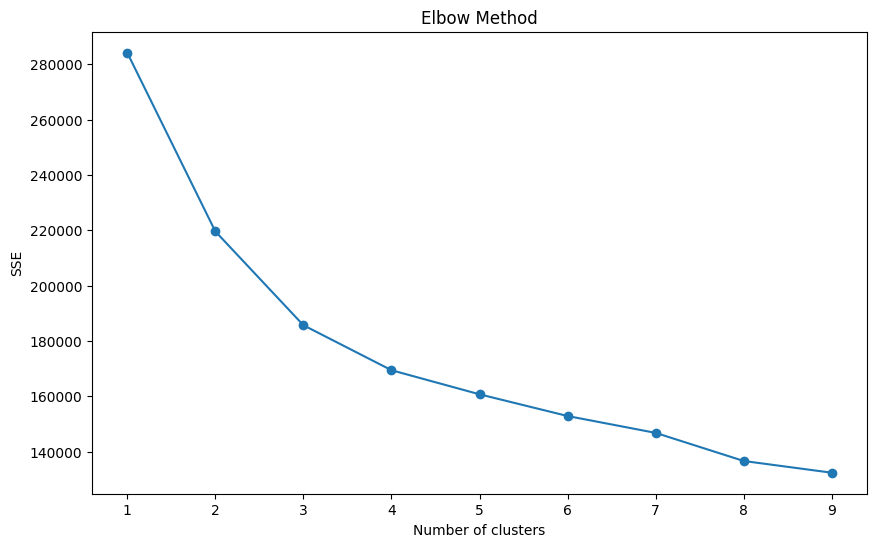

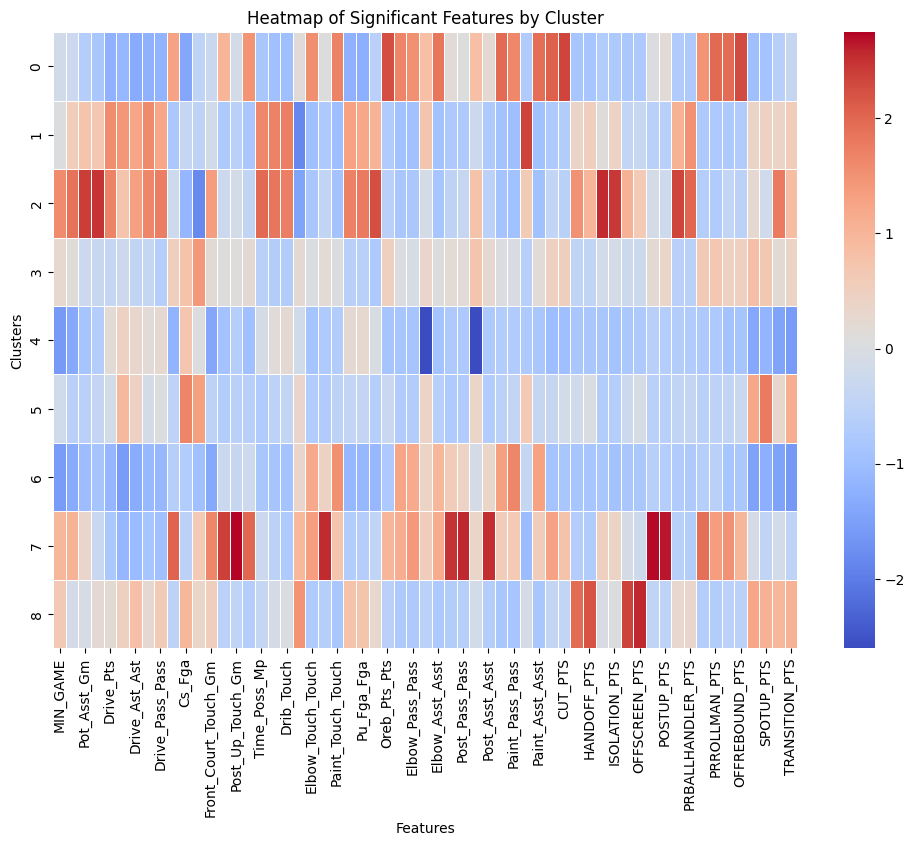

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# df = pd.read_csv("all_seasons_df_try2.csv")
df = pd.read_csv("all_seasons_df_try2.csv")

# Selecting features:
features = df.drop(columns=['PLAYER_ID', 'PLAYER', 'TEAM', 'GP', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'PTS', 'Season ID', 'PTS_GAME', 'MIN', 'POSS', 'PIE', 'Passes', 'Reb_Chance_Gm', 'Def_Reb_Chance_Gm', 'Off_Reb_Chance_Gm', 'Drive_Fta_Fta', 'Elbow_Fta_Fta', 'Post_Fta_Fta', 'Paint_Fta_Fta', 'Passes_Rec_Gm', 'Asst_Pts_Cr']).columns

# Normalize the data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)

# Apply PCA with the maximum number of components
pca = PCA(n_components=len(features))  # Use all components
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=[f'PC{i+1}' for i in range(len(features))])

# Determine optimal number of clusters using Elbow Method
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

# Choose an optimal number of clusters (e.g., k=3)
clusters = 9
kmeans = KMeans(n_clusters = clusters, random_state = 42)
df['Cluster'] = kmeans.fit_predict(df_pca)

# # Display clustered data
df[['PLAYER', 'Cluster']]
df.to_csv(f"all_seasons_df_{clusters}_9292024.csv", index = False)

# Map original features back to the clusters by computing the mean of each feature in each cluster
cluster_means = df.groupby('Cluster')[features].mean()

# Normalize the cluster_means for better visualization in the heatmap
scaler_means = StandardScaler()
cluster_means_scaled = pd.DataFrame(scaler_means.fit_transform(cluster_means), columns=features)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_scaled, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Heatmap of Significant Features by Cluster')
plt.xlabel('Features')
plt.ylabel('Clusters')
plt.show()

In [92]:
# Creates new column called cluster for every season's all_players df

for year in years:
    df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")
    df['Cluster'] = None
    df.to_csv(f"{year}/{year}_all_players_try2.csv", index = False)

In [9]:
# Adds cluster to the df of each player

all_seasons_df = pd.read_csv("all_seasons_df_9_9292024.csv")

for i, year in enumerate(years):
    season_df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")
    season_id = int(seas_ids[i])
    
    relevant_rows = all_seasons_df[all_seasons_df['Season ID'] == int(season_id)]

    for i in range(len(relevant_rows)):
        player_name = relevant_rows.iloc[i]['PLAYER']
        player_cluster = relevant_rows.iloc[i]['Cluster']
        season_df.loc[season_df['PLAYER'] == player_name, 'Cluster'] = player_cluster

    # Save the updated season DataFrame back to the CSV file
    season_df.to_csv(f"{year}/{year}_all_players_try2_9292024.csv", index=False)

In [ ]:
# # Drops 7 players with the lowest minutes so that players can evenly be distributed into 30 teams of 7 players each

# df = pd.read_csv("2023-24/2023-24_all_players.csv")
# player_minutes = df["MIN"].tolist()
# player_minutes = np.array(player_minutes)
# indices = np.argpartition(player_minutes, 7)[:7]

# # Get the 9 smallest values using the indices
# smallest_values = player_minutes[indices]

# # Sort the indices and values
# sorted_indices = indices[np.argsort(smallest_values)]
# sorted_values = np.sort(smallest_values)

# dropping_indices = sorted_indices.tolist()
# df = df.drop(dropping_indices, axis = 0)
# print(len(df))
# df.to_csv("2023-24/2023-24_all_players.csv", index = False)

In [115]:
# # Reordering the position of the columns

# df = pd.read_csv("2023-24/2023-24_all_players.csv")
# for i in range(len(df)):
#     df.loc[i, 'POSS_GAME'] = int(df.loc[i, 'POSS']) / int(df.loc[i, 'GP'])
#     df.loc[i, 'POSS_PER_82'] = int(df.loc[i, 'POSS']) / 82

# reference_column = 'POSS'
# new_column_1 = 'POSS_GAME'
# new_column_2 = 'POSS_PER_82'


# columns = list(df.columns)
# reference_position = columns.index(reference_column)

# columns.insert(reference_position + 1, columns.pop(columns.index(new_column_1)))
# columns.insert(reference_position + 2, columns.pop(columns.index(new_column_2)))

# df = df[columns]
# df.to_csv("2023-24/2023-24_all_players.csv", index = False)

In [116]:
# # Creating folders for each
# df = pd.read_csv("2023-24/2023-24_all_players.csv")

# for i in range(0, 8):
#     cluster_df = pd.DataFrame(columns = df.columns)
#     cluster_df.to_csv(f"2023-24/cluster_{i}.csv", index = False)

In [117]:
# df = pd.read_csv("2023-24/2023-24_all_players.csv")
# #df = df.drop(df.columns[0], axis = 1)

# for i in range(len(df)):
#     cluster_value = df.loc[i, "Cluster"]
#     for j in range(0, 8):
#         if cluster_value == j:
#             row = df.iloc[[i]]
#             cluster_df = pd.read_csv(f"2023-24/cluster_{j}.csv")
#             cluster_df = pd.concat([cluster_df, row], ignore_index = True)
#             cluster_df.to_csv(f"2023-24/cluster_{j}.csv", index = False)

# #df.to_csv("2023-24/2023-24_all_players.csv", index = False)
# #df

/var/folders/4t/y4bl6hxn2_3dh0qt1ms8dpyr0000gn/T/ipykernel_3976/3971127249.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cluster_df = pd.concat([cluster_df, row], ignore_index = True)
/var/folders/4t/y4bl6hxn2_3dh0qt1ms8dpyr0000gn/T/ipykernel_3976/3971127249.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cluster_df = pd.concat([cluster_df, row], ignore_index = True)
/var/folders/4t/y4bl6hxn2_3dh0qt1ms8dpyr0000gn/T/ipykernel_3976/3971127249.py:10: FutureWarning: The behavior of DataF

In [ ]:
# zero = pd.read_csv("2023-24/cluster_0.csv")

# df_sorted = zero.sort_values(by='PIE', ascending=False)
# df_sorted = df_sorted.reset_index(drop=True)


# for i in range(len(df_sorted)):
#     df_sorted.loc[i, 'Rank'] = i + 1
    
# df_sorted

In [132]:
team_df = pd.read_csv("2023-24/2023-24_team_dirty.csv")

total_sum = 0
for i in range(len(team_df)):
    team_touches = float(team_df.loc[i, 'TOUCHES'])
    total_sum += team_touches

average_touches_tm = total_sum / 30
print(average_touches_tm)

402.29333333333335


402.29333333333335 is the average number of touches a team in the NBA has per game

In [5]:
lineup_dfs = []

for year in years:
    df = pd.read_csv(f"{year}/{year}_lineups.csv")
    lineup_dfs.append(df)

final_df = pd.concat(lineup_dfs, ignore_index = True)
final_df.to_csv("all_lineups.csv")

In [15]:
# Finding columns that are going to be used to calculate synergy

exclude_columns = ['PLAYER_ID', 'PLAYER', 'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'PTS', 'Season ID', 'PTS_GAME', 'MIN_GAME', 'POSS', 'PIE', 'Passes']

include_columns = [col for col in df.columns if col not in exclude_columns]

teams_list = []

In [ ]:
# Functions to calculate synergy between lineups

# Finding distance between two players
def compute_distance(list1, list2):
    return np.sqrt(np.
                   sum((np.array(list1) - np.array(list2))**2))

# Finding distance between all players on team
def sum_of_distances(lists):
    pairs = itertools.combinations(lists, 2)
    
    total_distance = sum(compute_distance(list1, list2) for list1, list2 in pairs)
    
    return total_distance

In [11]:
# Developing function to calculate synergy between teams

def calc_synergy(team, df):
    team_array = []
    team_ints_array = []

    for i in range(len(df)):
        teams = df.loc[i, 'TEAM']
        if teams == team:
            team_ints_array.append(i)

    for int in team_ints_array:
        row = df.loc[int, include_columns]
        row_list = row.tolist()
        team_array.append(row_list)

    synergy = sum_of_distances(team_array)
    return synergy

df = pd.read_csv("2023-24/2023-24_all_players_try2.csv")

bos_synergy = calc_synergy('DEN', df)
bos_synergy

4658.661605106624

In [38]:
# I want to remove Non-Factor Guards and Non-Factor Bigs from the df

df = pd.read_csv("2023-24/2023-24_all_players_try2.csv")

rows_drop = []
clusters_drop = [2, 4]

for i in range(len(df)):
    cluster = df.loc[i, 'Cluster']
    if cluster in clusters_drop:
        rows_drop.append(i)

df = df.drop(rows_drop, axis = 0)
top_8 = df.groupby('TEAM').apply(lambda x: x.nlargest(8, 'MIN')).reset_index(drop=True)
top_8.to_csv("2023-24/top_8.csv", index = False)

/var/folders/4t/y4bl6hxn2_3dh0qt1ms8dpyr0000gn/T/ipykernel_96023/3617367247.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_8 = df.groupby('TEAM').apply(lambda x: x.nlargest(8, 'MIN')).reset_index(drop=True)


In [39]:
# Finding synergy between all team lineups

# df = pd.read_csv("2023-24/2023-24_all_players_try2.csv")
top_8 = pd.read_csv("2023-24/top_8.csv")
teams_synergy = pd.DataFrame()
teams_synergy['Teams'] = teams_list

for i, team in enumerate(teams_list):
    team_synergy = calc_synergy(team, top_8)
    teams_synergy.loc[i, 'Synergy'] = team_synergy

teams_synergy = teams_synergy.sort_values(by='Synergy', ascending=False)

teams_synergy.to_csv("2023-24/2023-24_synergy.csv")
teams_synergy

,Teams,Synergy
8,SAC,1088.760961
14,ATL,1071.773837
4,DEN,1028.452282
11,LAL,1016.754588
12,PHI,1002.823599
17,HOU,986.009872
10,CHI,983.923842
3,NYK,963.297435
29,POR,928.457711
0,DAL,922.612117


Player Groups:

0- Non-Shooting Bigs

1- Pure Point Guards

2- Non-Factor Players

3- Role Player Guards

4- Ball-Dominant Players

5- Finge Star Forwards

6- Catch-and-Shoot Specialists

7- Versatile Bigs

8- Fringe Star Guards